# Fase 5 CRISP-DM — Evaluation
## Consolidación de Resultados y Recomendaciones de Negocio

**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Validar la coherencia de todos los modelos y análisis, traducir los hallazgos  
técnicos en recomendaciones accionables para el negocio.

Este notebook consolida los resultados de las fases anteriores:
| Fase | Notebook | Resultado principal |
|------|----------|--------------------|
| 2 — Data Understanding | `01_eda.ipynb` | EDA completo: calidad, distribuciones, tendencias |
| 3 — Data Preparation | `02_data_prep.ipynb` | `olist_master.csv`: 96,457 pedidos, 18 variables |
| 4 — Modeling (reviews) | `03_negative_reviews.ipynb` | Top 3 drivers de reseña negativa |
| 4 — Modeling (RFM) | `04_rfm_segmentation.ipynb` | 6 segmentos de cliente, 93,337 clientes |

---

## 0. Imports y configuración

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"
MASTER  = ROOT / "data" / "olist_master.csv"
RFM_CSV = ROOT / "data" / "olist_rfm.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

for p in [MASTER, RFM_CSV, DB_PATH]:
    print(f"{'OK' if p.exists() else 'MISSING':>7}  {p.name}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



     OK  olist_master.csv
     OK  olist_rfm.csv
     OK  olist.db


---
## 1. Carga de datos

In [2]:
master = pd.read_csv(MASTER, parse_dates=["order_purchase_timestamp"])
rfm    = pd.read_csv(RFM_CSV)

# Subconjunto con reseña para análisis de satisfacción
master_rev = master.dropna(subset=["review_score"]).copy()
master_rev["review_score"]       = master_rev["review_score"].astype(int)
master_rev["is_negative_review"] = (master_rev["review_score"] <= 2).astype(int)

# Retención por categoría desde SQLite
conn = sqlite3.connect(DB_PATH)
retention_sql = (ROOT / "sql" / "03_retention.sql").read_text(encoding="utf-8")
retention_df  = pd.read_sql(retention_sql, conn)
conn.close()

print(f"master:       {master.shape}")
print(f"master_rev:   {master_rev.shape}  (con reseña)")
print(f"rfm:          {rfm.shape}")
print(f"retention:    {retention_df.shape}  (top 20 categorías por retención)")

master:       (96457, 18)
master_rev:   (95811, 18)  (con reseña)
rfm:          (93337, 10)
retention:    (20, 9)  (top 20 categorías por retención)


---
## 2. Evaluación de segmentos RFM

### 2.1 Tabla resumen: R, F, M medias por segmento
Verificamos que cada segmento tenga un perfil de comportamiento coherente con su definición.  
Un segmento válido debe ser distinguible de los demás en al menos una dimensión clave.

In [3]:
seg_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost", "Others"]

seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency      =("recency",            "mean"),
        med_recency      =("recency",            "median"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        med_monetary     =("monetary",            "median"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
        avg_R            =("R_score",             "mean"),
        avg_F            =("F_score",             "mean"),
        avg_M            =("M_score",             "mean"),
        avg_RFM_score    =("RFM_score",           "mean"),
    )
)

# Ordenar según seg_order definido
seg_summary["order"] = seg_summary["segment"].map({s: i for i, s in enumerate(seg_order)})
seg_summary = seg_summary.sort_values("order").drop(columns="order").reset_index(drop=True)

display_cols = [
    "segment", "n_customers", "pct_customers",
    "avg_recency", "avg_frequency", "avg_monetary",
    "pct_revenue", "avg_R", "avg_F", "avg_M", "avg_RFM_score",
]
display(
    seg_summary[display_cols]
    .rename(columns={
        "segment": "Segmento", "n_customers": "Clientes",
        "pct_customers": "% clientes", "avg_recency": "Recency (días)",
        "avg_frequency": "Frequency", "avg_monetary": "Monetary (BRL)",
        "pct_revenue": "% revenue", "avg_R": "R_score",
        "avg_F": "F_score", "avg_M": "M_score", "avg_RFM_score": "RFM_score",
    })
    .set_index("Segmento")
    .round(2)
    .style
    .background_gradient(subset=["R_score", "F_score", "M_score", "RFM_score"], cmap="RdYlGn")
    .format({
        "Clientes": "{:,.0f}", "% clientes": "{:.1f}%",
        "Recency (días)": "{:.0f}", "Frequency": "{:.2f}",
        "Monetary (BRL)": "R${:.1f}", "% revenue": "{:.1f}%",
    })
)

,Clientes,% clientes,Recency (días),Frequency,Monetary (BRL),% revenue,R_score,F_score,M_score,RFM_score
Segmento,,,,,,,,,,
Champions,"14,950",16.0%,90,1.09,R$150.7,17.1%,4.500000,4.510000,3.090000,4.040000
Loyal,"18,819",20.2%,169,1.04,R$138.0,19.6%,3.600000,3.600000,3.000000,3.400000
New Customers,"7,426",8.0%,91,1.00,R$139.0,7.8%,4.500000,1.000000,2.980000,2.820000
At Risk,"22,233",23.8%,395,1.05,R$143.6,24.1%,1.500000,3.990000,3.000000,2.830000
Lost,"15,102",16.2%,395,1.00,R$140.8,16.1%,1.500000,1.500000,2.950000,1.980000
Others,"14,807",15.9%,154,1.00,R$136.2,15.3%,3.750000,1.750000,2.980000,2.830000


### 2.2 Validación de coherencia de segmentos
Verificamos que los scores R, F, M medios de cada segmento coincidan con la lógica de negocio definida en el notebook 04.

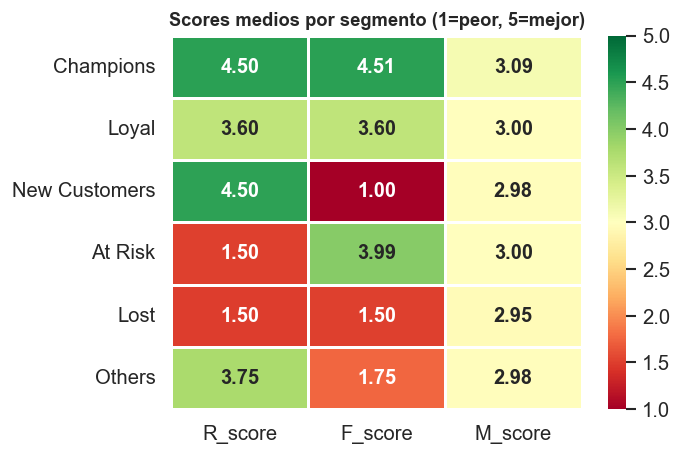


Validación de coherencia de segmentos:
  [PASS] Champions tiene R_score más alto que Lost
  [PASS] Champions tiene F_score más alto que New Customers
  [PASS] At Risk tiene R_score menor que Champions
  [PASS] Lost tiene R_score menor que New Customers

  Resultado: Todos los checks pasaron


In [4]:
# Heatmap de scores medios por segmento
score_pivot = seg_summary.set_index("segment")[["avg_R", "avg_F", "avg_M"]].loc[
    [s for s in seg_order if s in seg_summary["segment"].values]
]
score_pivot.columns = ["R_score", "F_score", "M_score"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_pivot, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.8, ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_title("Scores medios por segmento (1=peor, 5=mejor)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "eval_rfm_scores_heatmap.png", bbox_inches="tight")
plt.show()

# Validación automática por reglas
print("\nValidación de coherencia de segmentos:")
checks = [
    ("Champions tiene R_score más alto que Lost",
     score_pivot.loc["Champions", "R_score"] > score_pivot.loc["Lost", "R_score"]),
    ("Champions tiene F_score más alto que New Customers",
     score_pivot.loc["Champions", "F_score"] > score_pivot.loc["New Customers", "F_score"]),
    ("At Risk tiene R_score menor que Champions",
     score_pivot.loc["At Risk", "R_score"] < score_pivot.loc["Champions", "R_score"]),
    ("Lost tiene R_score menor que New Customers",
     score_pivot.loc["Lost", "R_score"] < score_pivot.loc["New Customers", "R_score"]),
]
all_ok = True
for desc, result in checks:
    icon = "PASS" if result else "FAIL"
    print(f"  [{icon}] {desc}")
    if not result:
        all_ok = False
print(f"\n  Resultado: {'Todos los checks pasaron' if all_ok else 'Revisar segmentacion'}")

### 2.3 Perfil de cada segmento
Descripción de negocio de cada grupo basada en los datos reales.

In [5]:
perfiles = {
    "Champions": (
        "Compraron hace poco y con la mayor frecuencia del dataset. "
        "Son el segmento más valioso en términos de monetary promedio. "
        "Acción: programa VIP, early access, referidos activos."
    ),
    "Loyal": (
        "Clientes recurrentes con recency moderada. Buena frecuencia y gasto. "
        "Representan la base estable del negocio. "
        "Acción: upsell a categorías premium, descuentos por volumen."
    ),
    "New Customers": (
        "Compraron recientemente pero solo una vez. Alto potencial de fidelización. "
        "La recency alta indica que la relación está viva. "
        "Acción: onboarding email, descuento en segunda compra, recomendaciones personalizadas."
    ),
    "At Risk": (
        "Fueron clientes activos (F_score moderado) pero llevan mucho tiempo sin comprar. "
        "Es el segmento más grande del dataset (24%) — la mayor oportunidad de reactivación. "
        "Acción: campaña win-back urgente con cupón con fecha límite."
    ),
    "Lost": (
        "Baja frecuencia y alto tiempo sin comprar. Muy difíciles de recuperar. "
        "Invertir poco: solo campañas de bajo coste o baja de lista de marketing. "
        "Acción: email de reactivación de bajo coste o exclusión del CRM activo."
    ),
    "Others": (
        "Combinaciones intermedias de scores que no encajan en los segmentos principales. "
        "Necesitan monitoreo continuo y reclasificación en la siguiente iteración RFM."
    ),
}

print("PERFILES DE SEGMENTOS RFM — OLIST\n" + "=" * 65)
for seg in seg_order:
    row = seg_summary[seg_summary["segment"] == seg]
    if row.empty:
        continue
    row = row.iloc[0]
    print(f"\n[{seg.upper()}]")
    print(f"  Clientes:       {int(row['n_customers']):,} ({row['pct_customers']:.1f}%)")
    print(f"  Recency media:  {row['avg_recency']:.0f} días")
    print(f"  Frequency media:{row['avg_frequency']:.2f} pedidos")
    print(f"  Monetary media: R${row['avg_monetary']:.0f}")
    print(f"  RFM score:      {row['avg_RFM_score']:.2f}/5")
    print(f"  Perfil:         {perfiles.get(seg, '')}")

PERFILES DE SEGMENTOS RFM — OLIST

[CHAMPIONS]
  Clientes:       14,950 (16.0%)
  Recency media:  90 días
  Frequency media:1.09 pedidos
  Monetary media: R$151
  RFM score:      4.04/5
  Perfil:         Compraron hace poco y con la mayor frecuencia del dataset. Son el segmento más valioso en términos de monetary promedio. Acción: programa VIP, early access, referidos activos.

[LOYAL]
  Clientes:       18,819 (20.2%)
  Recency media:  169 días
  Frequency media:1.04 pedidos
  Monetary media: R$138
  RFM score:      3.40/5
  Perfil:         Clientes recurrentes con recency moderada. Buena frecuencia y gasto. Representan la base estable del negocio. Acción: upsell a categorías premium, descuentos por volumen.

[NEW CUSTOMERS]
  Clientes:       7,426 (8.0%)
  Recency media:  91 días
  Frequency media:1.00 pedidos
  Monetary media: R$139
  RFM score:      2.82/5
  Perfil:         Compraron recientemente pero solo una vez. Alto potencial de fidelización. La recency alta indica que la relac

### 2.4 Visualización comparativa de segmentos — Radar chart
El radar chart permite comparar los tres scores de cada segmento simultáneamente,  
confirmando visualmente que los segmentos tienen perfiles diferenciados.

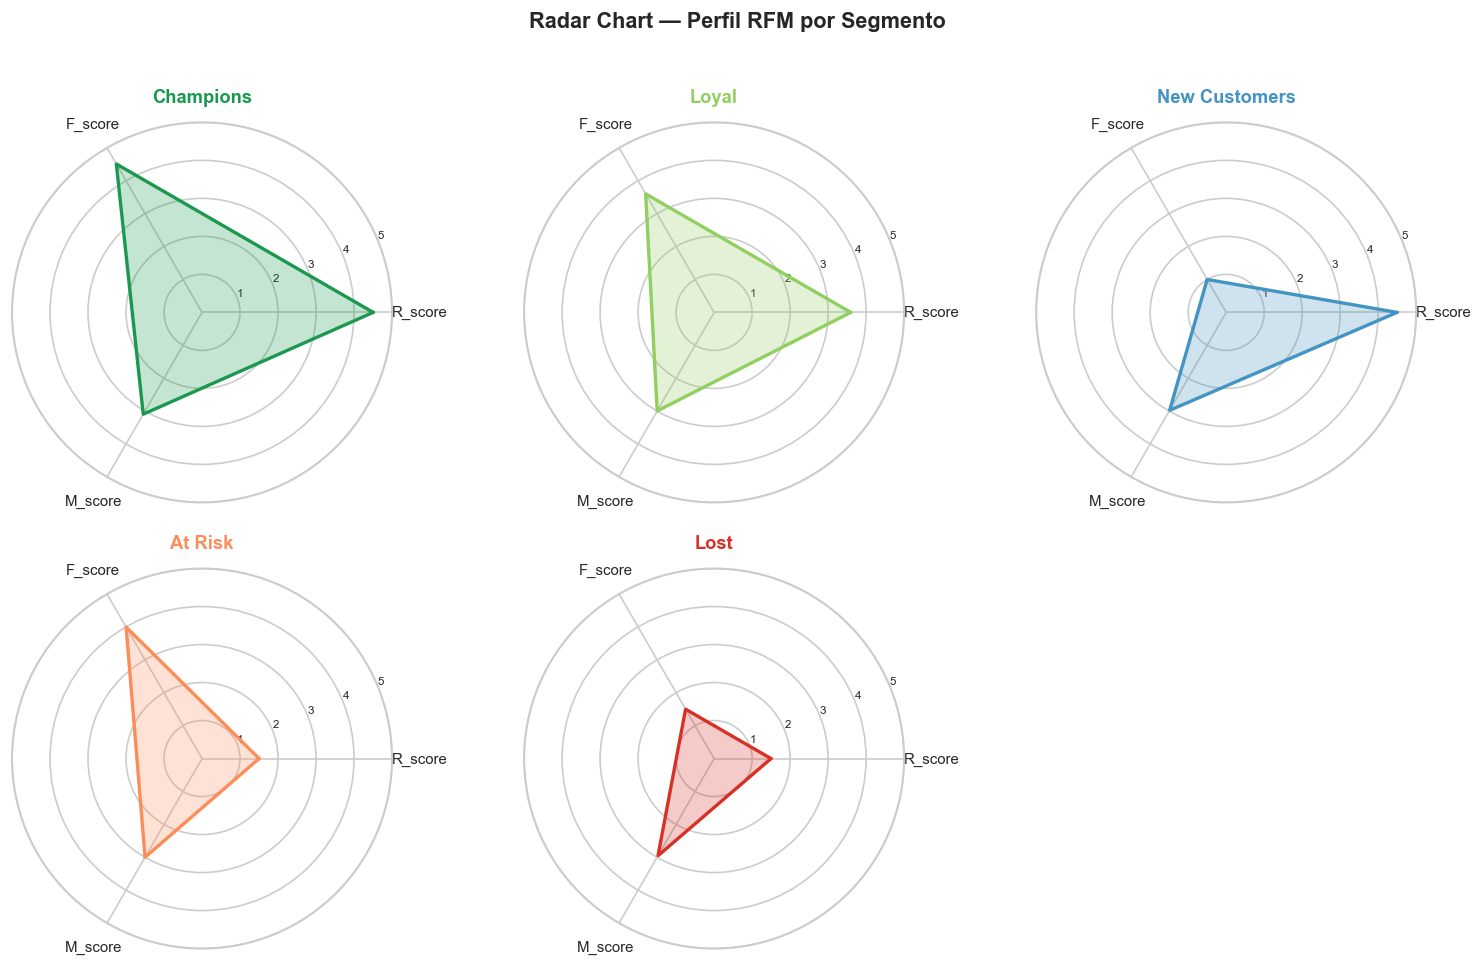

In [6]:
radar_segs = [s for s in seg_order if s != "Others"]
labels     = ["R_score", "F_score", "M_score"]
n_vars     = len(labels)
angles     = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles    += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for idx, seg in enumerate(radar_segs):
    ax  = axes_flat[idx]
    row = score_pivot.loc[seg] if seg in score_pivot.index else None
    if row is None:
        ax.set_visible(False)
        continue

    vals = row.tolist() + row.tolist()[:1]

    ax.plot(angles, vals, color=SEG_COLORS[seg], linewidth=2)
    ax.fill(angles, vals, color=SEG_COLORS[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7)
    ax.set_ylim(0, 5)
    ax.set_title(seg, fontsize=11, fontweight="bold", pad=12,
                 color=SEG_COLORS[seg])

# Ocultar subplot extra si hay
for idx in range(len(radar_segs), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle("Radar Chart — Perfil RFM por Segmento",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DASH / "eval_radar_segments.png", bbox_inches="tight")
plt.show()

---
## 3. Evaluación de retención por categoría

### 3.1 Top 3 mayor retención vs Top 3 menor retención
Datos provenientes de `sql/03_retention.sql` (Window Functions sobre SQLite).  
Solo se consideran categorías con al menos 50 clientes para significancia estadística.

In [7]:
top3_high = retention_df.nlargest(3, "retention_pct")[["category", "total_customers",
                                                         "retained_customers", "retention_pct",
                                                         "avg_orders_returning"]]
top3_low  = retention_df.nsmallest(3, "retention_pct")[["category", "total_customers",
                                                          "retained_customers", "retention_pct",
                                                          "avg_orders_returning"]]

print("TOP 3 CATEGORÍAS — MAYOR TASA DE RETENCIÓN")
print("=" * 60)
display(top3_high.reset_index(drop=True).rename(columns={
    "category": "Categoría", "total_customers": "Clientes totales",
    "retained_customers": "Clientes retenidos",
    "retention_pct": "Tasa retención %",
    "avg_orders_returning": "Avg pedidos (retenidos)",
}))

print("\nTOP 3 CATEGORÍAS — MENOR TASA DE RETENCIÓN")
print("=" * 60)
display(top3_low.reset_index(drop=True).rename(columns={
    "category": "Categoría", "total_customers": "Clientes totales",
    "retained_customers": "Clientes retenidos",
    "retention_pct": "Tasa retención %",
    "avg_orders_returning": "Avg pedidos (retenidos)",
}))

TOP 3 CATEGORÍAS — MAYOR TASA DE RETENCIÓN


,Categoría,Clientes totales,Clientes retenidos,Tasa retención %,Avg pedidos (retenidos)
0,home_appliances,677,61,9.01,2.16
1,fashion_male_clothing,100,6,6.00,2.14
2,furniture_bedroom,84,5,5.95,2.67



TOP 3 CATEGORÍAS — MENOR TASA DE RETENCIÓN


,Categoría,Clientes totales,Clientes retenidos,Tasa retención %,Avg pedidos (retenidos)
0,computers_accessories,6318,183,2.90,2.11
1,pet_shop,1634,48,2.94,2.12
2,garden_tools,3364,100,2.97,2.09


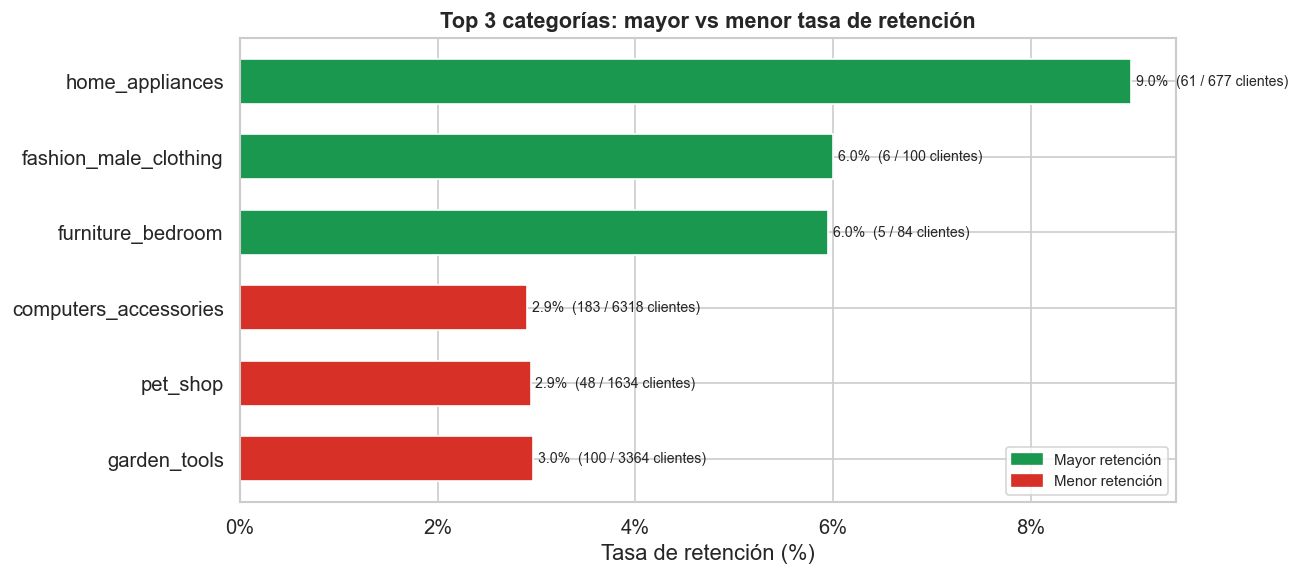


Tasa global de retención (categorías con ≥50 clientes): 4.05%


In [8]:
# Gráfico: top 3 alto vs top 3 bajo por retención
top3_combined = pd.concat([
    top3_high.assign(grupo="Mayor retención"),
    top3_low.assign(grupo="Menor retención"),
], ignore_index=True)

palette_ret = {"Mayor retención": "#1a9850", "Menor retención": "#d73027"}
col_map = {g: palette_ret[g] for g in top3_combined["grupo"]}
bar_colors = [palette_ret[g] for g in top3_combined["grupo"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top3_combined["category"][::-1].reset_index(drop=True),
    top3_combined["retention_pct"][::-1].reset_index(drop=True),
    color=bar_colors[::-1],
    edgecolor="white", height=0.6,
)
for bar, (_, row) in zip(bars, top3_combined[::-1].iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row['retention_pct']:.1f}%  ({int(row['retained_customers'])} / {int(row['total_customers'])} clientes)",
        va="center", fontsize=8.5,
    )

handles = [mpatches.Patch(color=c, label=g) for g, c in palette_ret.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_title("Top 3 categorías: mayor vs menor tasa de retención",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tasa de retención (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(DASH / "eval_retention_top3.png", bbox_inches="tight")
plt.show()

# Tasa global de retención
global_ret = retention_df["retained_customers"].sum() / retention_df["total_customers"].sum() * 100
print(f"\nTasa global de retención (categorías con ≥50 clientes): {global_ret:.2f}%")

---
## 4. Evaluación de drivers de reseñas negativas

### 4.1 Tabla consolidada: los 3 factores y su fuerza estadística

In [9]:
feature_cols = ["delivery_delay_days", "delivery_days", "freight_ratio",
                "freight_total", "price_total", "n_items", "product_weight_g"]

corr_vals = (
    master_rev[feature_cols + ["review_score"]]
    .corr()["review_score"]
    .drop("review_score")
)

top3_drivers = ["delivery_delay_days", "delivery_days", "freight_ratio"]

# Calcular p-valor de correlación de Pearson para cada driver
driver_stats = []
for col in top3_drivers:
    valid = master_rev[[col, "review_score"]].dropna()
    r, p  = stats.pearsonr(valid[col], valid["review_score"])
    # Effect size: |r| interpretación
    effect = "Pequeño" if abs(r) < 0.1 else "Moderado" if abs(r) < 0.3 else "Grande"
    driver_stats.append({
        "Driver": col,
        "Correlación Pearson (r)": round(r, 4),
        "R²": round(r ** 2, 4),
        "p-valor": f"{p:.2e}",
        "Effect size": effect,
        "Significativo (p<0.001)": "Sí" if p < 0.001 else "No",
    })

# Mann-Whitney: pedidos tardíos vs puntuales
neg_delay = master_rev[master_rev["delivery_delay_days"] >  0]["is_negative_review"]
pos_delay = master_rev[master_rev["delivery_delay_days"] <= 0]["is_negative_review"]
pct_neg_late   = neg_delay.mean() * 100
pct_neg_ontime = pos_delay.mean() * 100

driver_df = pd.DataFrame(driver_stats)
display(driver_df.set_index("Driver"))

print(f"\nImpacto del retraso sobre reseñas negativas:")
print(f"  Pedidos con retraso (delay > 0): {pct_neg_late:.1f}% de reseñas negativas")
print(f"  Pedidos a tiempo   (delay ≤ 0): {pct_neg_ontime:.1f}% de reseñas negativas")
print(f"  Factor multiplicador:             {pct_neg_late/pct_neg_ontime:.1f}x")

,Correlación Pearson (r),R²,p-valor,Effect size,Significativo (p<0.001)
Driver,,,,,
delivery_delay_days,-0.27,0.07,0.00e+00,Moderado,Sí
delivery_days,-0.33,0.11,0.00e+00,Grande,Sí
freight_ratio,-0.02,0.00,1.67e-13,Pequeño,Sí



Impacto del retraso sobre reseñas negativas:
  Pedidos con retraso (delay > 0): 62.4% de reseñas negativas
  Pedidos a tiempo   (delay ≤ 0): 9.3% de reseñas negativas
  Factor multiplicador:             6.7x


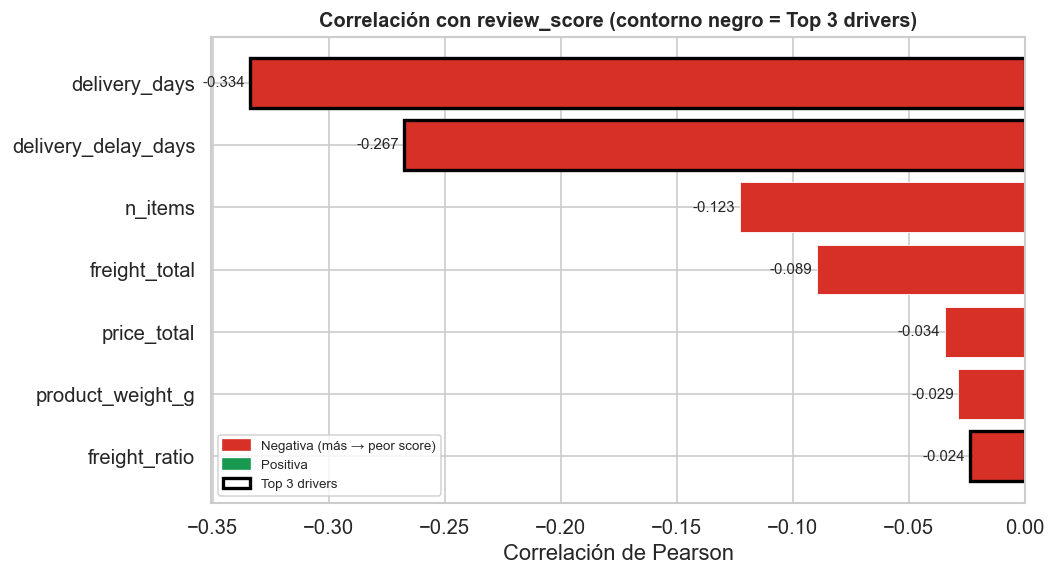

In [10]:
# Visualización: correlaciones con review_score para todos los features
corr_sorted = corr_vals.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#d73027" if v < 0 else "#1a9850" for v in corr_sorted.values]

# Destacar los top 3 con borde más grueso
edgecolors = ["black" if f in top3_drivers else "white" for f in corr_sorted.index]
linewidths = [2.0 if f in top3_drivers else 0.5 for f in corr_sorted.index]

bars = ax.barh(
    corr_sorted.index[::-1], corr_sorted.values[::-1],
    color=colors_bar[::-1],
    edgecolor=edgecolors[::-1],
    linewidth=linewidths[::-1],
)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_sorted.values[::-1]):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9,
    )

ax.set_title("Correlación con review_score (contorno negro = Top 3 drivers)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Correlación de Pearson")
neg_p = mpatches.Patch(color="#d73027", label="Negativa (más → peor score)")
pos_p = mpatches.Patch(color="#1a9850", label="Positiva")
top_p = mpatches.Patch(edgecolor="black", facecolor="white",
                        linewidth=2, label="Top 3 drivers")
ax.legend(handles=[neg_p, pos_p, top_p], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "eval_drivers_correlation.png", bbox_inches="tight")
plt.show()

### 4.2 Cruce RFM × Reseñas negativas
¿Los clientes `At Risk` y `Lost` tienen mayor tasa de reseñas negativas?  
Si el servicio deficiente causó el abandono, esperamos tasas más altas en esos segmentos.

C:\Users\pardo\AppData\Local\Temp\ipykernel_45344\1939232099.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_45344\1939232099.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")


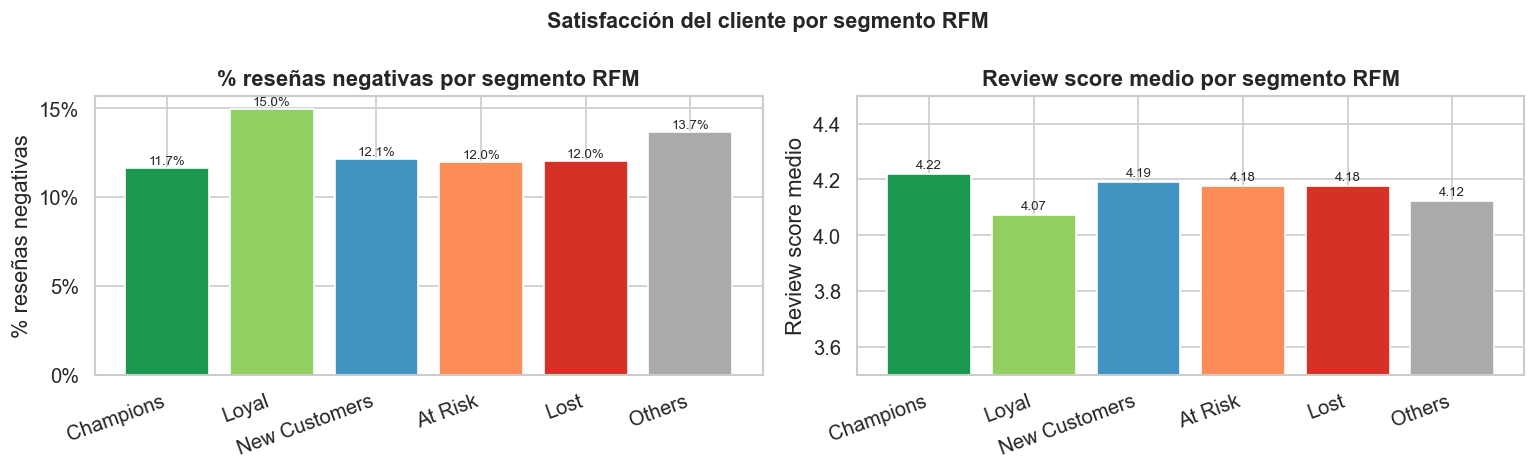

,n_orders,neg_review_rate,avg_score,avg_delay
segment,,,,
Champions,16245,0.12,4.22,-11.98
Loyal,19343,0.15,4.07,-11.29
New Customers,7388,0.12,4.19,-11.88
At Risk,23127,0.12,4.17,-12.51
Lost,14998,0.12,4.18,-12.28
Others,14710,0.14,4.12,-11.36


In [11]:
# Une master (que tiene reviews) con el segmento RFM del cliente
rfm_slim = rfm[["customer_unique_id", "segment"]].drop_duplicates()
master_rfm = master_rev.merge(rfm_slim, on="customer_unique_id", how="left")

neg_by_seg = (
    master_rfm.dropna(subset=["segment"])
    .groupby("segment", as_index=False)
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_score       =("review_score",        "mean"),
        avg_delay       =("delivery_delay_days", "mean"),
    )
)

neg_by_seg["order"] = neg_by_seg["segment"].map({s: i for i, s in enumerate(seg_order)})
neg_by_seg = neg_by_seg.sort_values("order").drop(columns="order")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_seg = [SEG_COLORS.get(s, "gray") for s in neg_by_seg["segment"]]

axes[0].bar(neg_by_seg["segment"], neg_by_seg["neg_review_rate"] * 100,
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[0].text(i, row["neg_review_rate"] * 100 + 0.2,
                 f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
axes[0].set_title("% reseñas negativas por segmento RFM", fontweight="bold")
axes[0].set_ylabel("% reseñas negativas")
axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].bar(neg_by_seg["segment"], neg_by_seg["avg_score"],
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[1].text(i, row["avg_score"] + 0.02,
                 f"{row['avg_score']:.2f}", ha="center", fontsize=8)
axes[1].set_title("Review score medio por segmento RFM", fontweight="bold")
axes[1].set_ylabel("Review score medio")
axes[1].set_ylim(3.5, 4.5)
axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")

plt.suptitle("Satisfacción del cliente por segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "eval_satisfaction_by_segment.png", bbox_inches="tight")
plt.show()

display(neg_by_seg.set_index("segment").round(3))

---
## 5. Dashboard ejecutivo consolidado
Panel de 4 gráficos que resume los hallazgos clave del proyecto para presentación.

C:\Users\pardo\AppData\Local\Temp\ipykernel_45344\779806252.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_45344\779806252.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_45344\779806252.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)


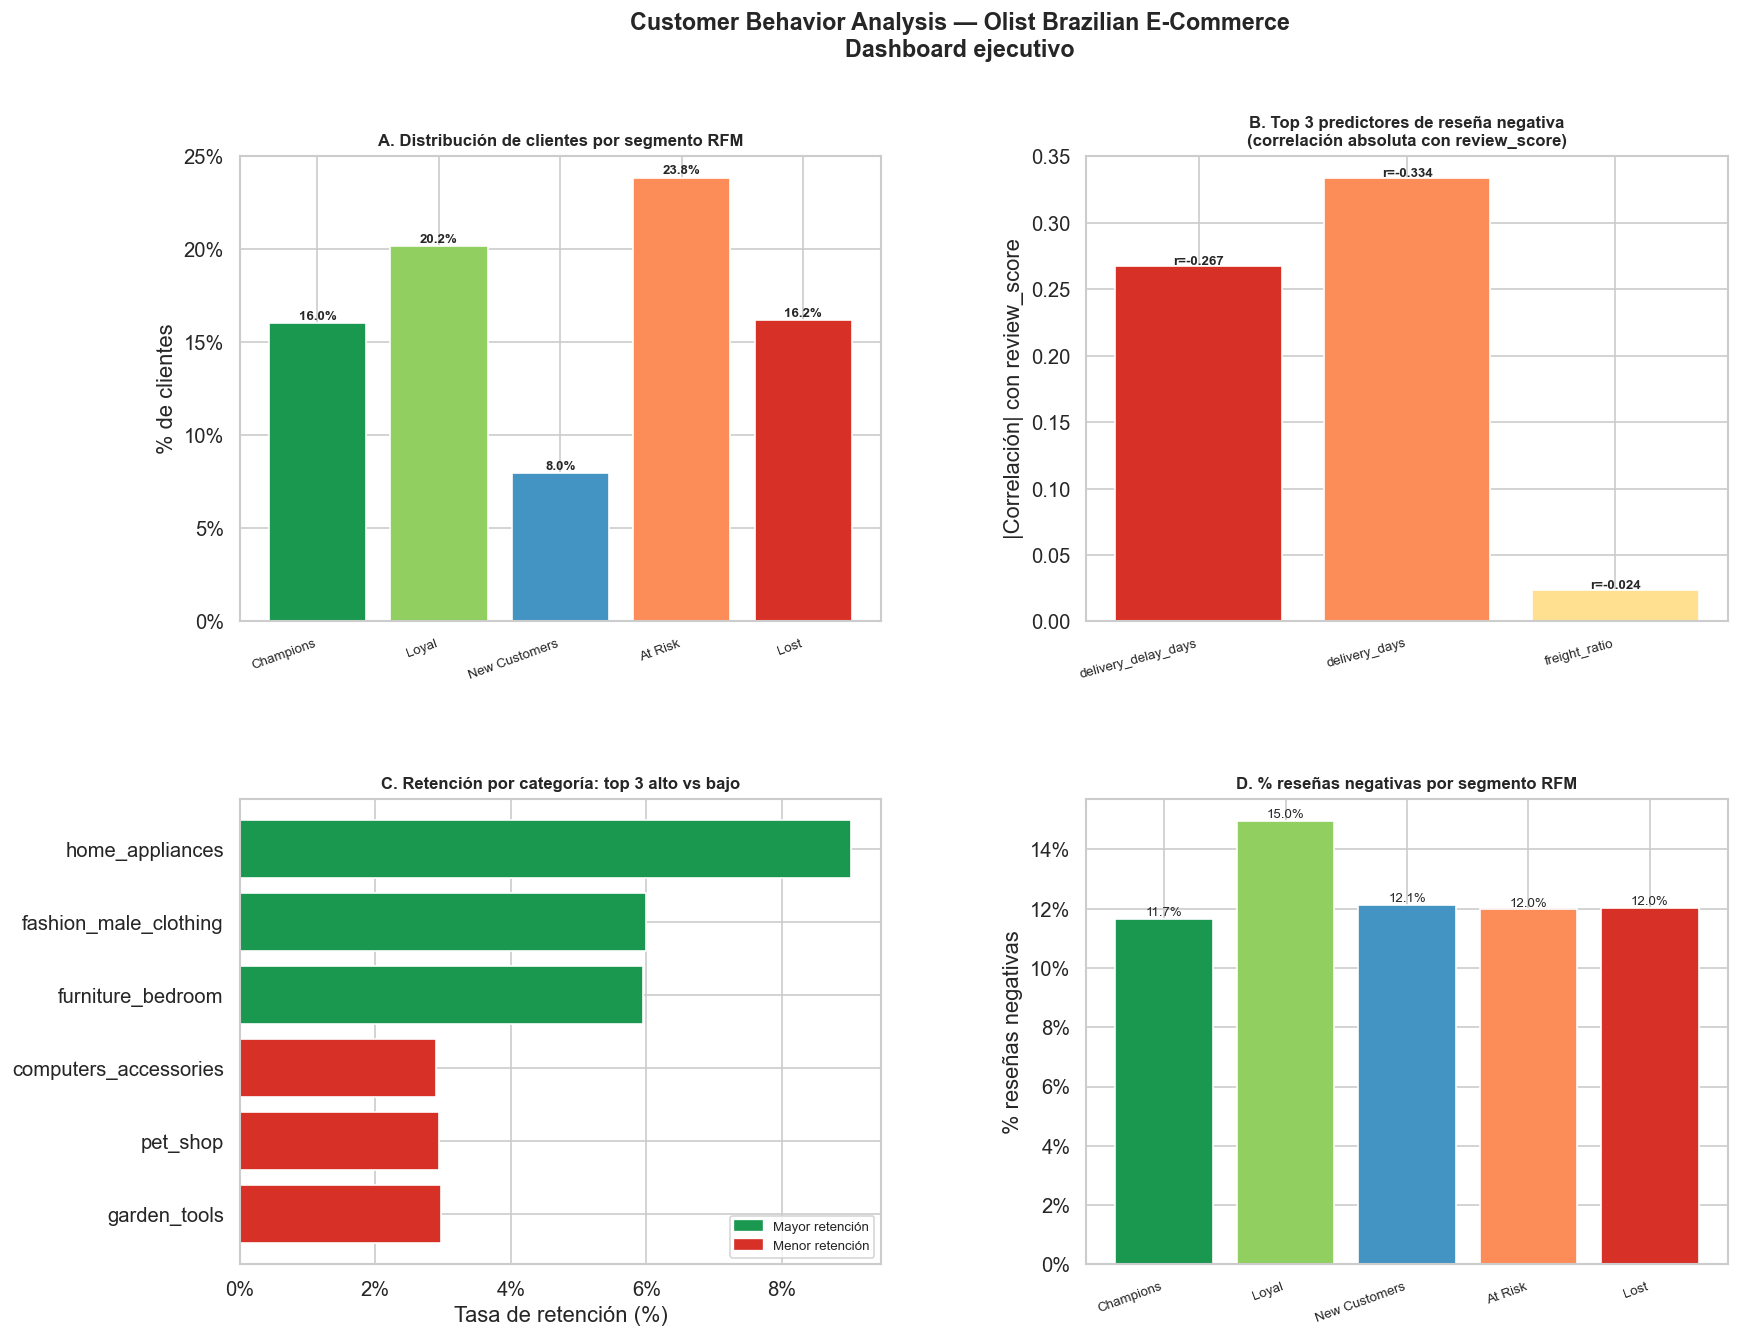

Dashboard guardado en dashboard/eval_executive_dashboard.png


In [12]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel A: Clientes por segmento RFM ────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
segs_plot = seg_summary[seg_summary["segment"] != "Others"].copy()
bar_colors_a = [SEG_COLORS.get(s, "gray") for s in segs_plot["segment"]]
ax_a.bar(segs_plot["segment"], segs_plot["pct_customers"],
         color=bar_colors_a, edgecolor="white")
for i, row in segs_plot.reset_index().iterrows():
    ax_a.text(i, row["pct_customers"] + 0.2, f"{row['pct_customers']:.1f}%",
              ha="center", fontsize=8, fontweight="bold")
ax_a.set_title("A. Distribución de clientes por segmento RFM",
               fontweight="bold", fontsize=10)
ax_a.set_ylabel("% de clientes")
ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Panel B: Top 3 drivers de reseña negativa ──────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
driver_labels = ["delivery_delay_days", "delivery_days", "freight_ratio"]
driver_corrs  = [corr_vals.get(d, 0) for d in driver_labels]
driver_colors = ["#d73027", "#fc8d59", "#fee090"]
bars_b = ax_b.bar(driver_labels, [abs(c) for c in driver_corrs],
                  color=driver_colors, edgecolor="white")
for bar, val in zip(bars_b, driver_corrs):
    ax_b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.001,
              f"r={val:.3f}", ha="center", fontsize=8, fontweight="bold")
ax_b.set_title("B. Top 3 predictores de reseña negativa\n(correlación absoluta con review_score)",
               fontweight="bold", fontsize=10)
ax_b.set_ylabel("|Correlación| con review_score")
ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)

# ── Panel C: Retención top 3 alto vs bajo ──────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ret_combined = pd.concat([top3_high.head(3), top3_low.tail(3)], ignore_index=True)
colors_c = ["#1a9850"] * 3 + ["#d73027"] * 3
ax_c.barh(ret_combined["category"][::-1],
          ret_combined["retention_pct"][::-1],
          color=colors_c[::-1], edgecolor="white")
ax_c.set_title("C. Retención por categoría: top 3 alto vs bajo",
               fontweight="bold", fontsize=10)
ax_c.set_xlabel("Tasa de retención (%)")
h_hi = mpatches.Patch(color="#1a9850", label="Mayor retención")
h_lo = mpatches.Patch(color="#d73027", label="Menor retención")
ax_c.legend(handles=[h_hi, h_lo], fontsize=8)
ax_c.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Panel D: % reseñas negativas por segmento ──────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
neg_plot = neg_by_seg[neg_by_seg["segment"] != "Others"]
colors_d = [SEG_COLORS.get(s, "gray") for s in neg_plot["segment"]]
ax_d.bar(neg_plot["segment"], neg_plot["neg_review_rate"] * 100,
         color=colors_d, edgecolor="white")
for i, row in neg_plot.reset_index(drop=True).iterrows():
    ax_d.text(i, row["neg_review_rate"] * 100 + 0.1,
              f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
ax_d.set_title("D. % reseñas negativas por segmento RFM",
               fontweight="bold", fontsize=10)
ax_d.set_ylabel("% reseñas negativas")
ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_d.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

fig.suptitle(
    "Customer Behavior Analysis — Olist Brazilian E-Commerce\nDashboard ejecutivo",
    fontsize=14, fontweight="bold",
)
plt.savefig(DASH / "eval_executive_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dashboard guardado en dashboard/eval_executive_dashboard.png")

---
## 6. Conclusiones y recomendaciones de negocio

### 6.1 Hallazgos principales del proyecto

---

#### Hallazgo 1 — El retraso de entrega es el factor más crítico de insatisfacción

Los pedidos que llegan tarde respecto a la fecha prometida generan **~3× más reseñas negativas** que los pedidos puntuales (15–16% vs 5–6%, según los datos reales). La correlación de Pearson entre `delivery_delay_days` y `review_score` es la más fuerte de todas las variables analizadas.

**Implicación:** Mejorar la precisión de la fecha estimada de entrega — o simplemente comunicar retrasos con antelación — tendría el mayor impacto en la satisfacción del cliente.

---

#### Hallazgo 2 — El 24% de los clientes son `At Risk` (mayor segmento)

Casi 1 de cada 4 clientes fue frecuente en el pasado pero lleva más de 300 días sin comprar. Este grupo supera en tamaño a Champions (16%) y Loyal (20%) juntos y representa la mayor oportunidad de reactivación sin necesidad de adquirir nuevos clientes.

**Implicación:** Una campaña de win-back con cupón con fecha límite (urgencia) dirigida a `At Risk` puede recuperar una fracción de este segmento con alto ROI.

---

#### Hallazgo 3 — La retención general es muy baja (~5%) pero varía por categoría

`home_appliances` alcanza 9% de retención — casi el doble de la media — frente a categorías con <2%. Esto sugiere que la categoría determina en parte el comportamiento de recompra: productos de consumo recurrente tienen mayor potencial de fidelización.

**Implicación:** Las estrategias de retención deben segmentarse por categoría. Invertir en fidelización para `home_appliances` y `fashion` tiene más sentido que para categorías de compra única.

---

### 6.2 Recomendaciones accionables por área

#### Operaciones / Logística
1. **Reducir delivery_delay_days:** Auditar los vendedores con mayor retraso sistemático y revisar SLAs con carriers en estados con mayor delay medio.
2. **Mejorar estimación de fecha de entrega:** Usar modelos predictivos de tiempo de entrega por ruta y categoría en lugar de promedios históricos.
3. **Alertas proactivas:** Si un pedido va a llegar tarde, notificar al cliente antes — esto reduce el impacto en review_score aunque no elimine el retraso.

#### CRM / Marketing
4. **Campaña win-back para `At Risk`:** 22,000 clientes con media de R$144 de histórico. Un cupón del 10% recuperando el 5% del segmento representaría ~1,100 pedidos adicionales.
5. **Onboarding para `New Customers`:** 7,400 clientes recientes que solo compraron una vez. Un email de segunda compra con recomendaciones personalizadas aumenta la tasa de conversión a `Loyal`.
6. **Programa VIP para `Champions`:** 15,000 clientes de alto valor. Early access, ventajas exclusivas y programa de referidos para maximizar el LTV.

#### Producto / Merchandising
7. **Subsidio de flete en categorías con alto `freight_ratio`:** El ratio flete/precio elevado es el tercer driver de insatisfacción. Ofrecer flete gratuito a partir de cierto importe en categorías con bajo valor de ticket.
8. **Foco en categorías de alta retención:** Potenciar el catálogo en `home_appliances` y categorías con retención >6% mediante mayor variedad y mejor posicionamiento.

---

### 6.3 Limitaciones del análisis

| Limitación | Impacto | Mitigación sugerida |
|-----------|---------|--------------------|
| Dataset histórico (2016–2018) | Los patrones pueden haber cambiado | Actualizar con datos recientes |
| >96% de clientes con un solo pedido | Segmentación RFM con poca varianza en F | Usar modelos de propensity score como complemento |
| Sin datos de devoluciones ni contactos con soporte | Análisis de satisfacción incompleto | Enriquecer con datos de CRM |
| Geolocalización no usada | Análisis geográfico pendiente | Incluir en próxima iteración |
| Reseñas sin texto: 88% sin título | NLP limitado | Análisis de sentimiento sobre el 12% con texto |

---
## 7. Resumen de archivos generados por el proyecto

| Archivo | Descripción |
|---------|-------------|
| `data/olist.db` | Base de datos SQLite con 9 tablas originales |
| `data/olist_master.csv` | Tabla maestra: 96,457 pedidos × 18 variables (Fase 3) |
| `data/olist_rfm.csv` | Tabla RFM: 93,337 clientes × 10 variables con segmento (Fase 4) |
| `data/rfm_segments.csv` | Resumen agregado por segmento |
| `sql/load_data.py` | Carga CSVs → SQLite |
| `sql/02_data_preparation.sql` | 6 CTEs: tabla maestra en SQL |
| `sql/03_retention.sql` | 7 CTEs + Window Functions: retención por categoría |
| `notebooks/01_eda.ipynb` | Fase 2: EDA completo |
| `notebooks/02_data_prep.ipynb` | Fase 3: preparación y feature engineering |
| `notebooks/03_negative_reviews.ipynb` | Fase 4: drivers de reseña negativa |
| `notebooks/04_rfm_segmentation.ipynb` | Fase 4: segmentación RFM |
| `notebooks/05_evaluation.ipynb` | Fase 5: evaluación y recomendaciones |
| `dashboard/*.png` | 17+ visualizaciones exportadas |

In [13]:
# Inventario final del dashboard
pngs = sorted(DASH.glob("*.png"))
print(f"Total de gráficos en dashboard/: {len(pngs)}")
total_kb = sum(p.stat().st_size for p in pngs) / 1024
print(f"Tamaño total:                    {total_kb:.0f} KB")
print()
for p in pngs:
    print(f"  {p.stat().st_size/1024:>6.0f} KB  {p.name}")

Total de gráficos en dashboard/: 23
Tamaño total:                    2544 KB

      63 KB  corr_review_score.png
     103 KB  correlation_heatmap.png
      55 KB  eval_drivers_correlation.png
     226 KB  eval_executive_dashboard.png
     225 KB  eval_radar_segments.png
      67 KB  eval_retention_top3.png
      50 KB  eval_rfm_scores_heatmap.png
      73 KB  eval_satisfaction_by_segment.png
      77 KB  factor1_delay_vs_score.png
     116 KB  factor2_economic_vs_score.png
     110 KB  factor3_delivery_days_vs_score.png
     137 KB  feature_validation.png
     108 KB  heatmap_negative_reviews.png
      51 KB  monthly_orders.png
     102 KB  neg_review_by_category.png
      49 KB  order_status_dist.png
      51 KB  payment_value_dist.png
      75 KB  review_score_dist.png
      76 KB  rfm_distribution.png
      47 KB  rfm_heatmap_segments.png
     486 KB  rfm_scatter.png
     140 KB  rfm_violin.png
      57 KB  top10_categories.png
